In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

import math
from functools import lru_cache
import numpy as np
import matplotlib.pyplot as plt

from augmented.laminar_tables import subset_pmf_cache, subpool_tensor
from augmented.laminar_benchmarks import (
    ExactPolicyEvaluator,
    dynamic_augmented_value,
    four_quantities,
    greedy_laminar_value,
    rollout_laminar_value,
    static_greedy_value,
)

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})


def caja(ax, x, y, texto, color, w=0.30, h=0.085):
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, fill=True,
                               facecolor='white', edgecolor=color, lw=1.6,
                               zorder=3))
    ax.text(x, y, texto, ha='center', va='center', fontsize=8.6,
            color=TINTA, zorder=4)


def flecha(ax, x1, y1, x2, y2, etiqueta, lado='center'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color=GRIS, lw=1.2))
    ax.text((x1 + x2) / 2 + (0.04 if lado == 'der' else -0.04 if lado == 'izq' else 0),
            (y1 + y2) / 2, etiqueta, ha='center', va='center', fontsize=7.8,
            color=TINTA,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.9))


def lienzo(ax, titulo):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.set_title(titulo, fontsize=10)


def estado_tras(ev, pool, R):
    '''Estado (mundos, acreditados) tras observar conteo R en pool desde la raiz.'''
    child = ev.all_worlds & ev.outcome_worlds[pool][R]
    assert ev.mass(child) > 0.0, (pool, R)
    return child, (pool if R == 0 else 0)


def ganancia(ev, worlds, cleared, pool):
    '''Ganancia inmediata esperada de probar pool en el estado dado.'''
    return sum(pr * rw for pr, _, _, rw in ev.branches(worlds, cleared, pool))


def hacer_V(ev):
    '''Funcion de valor optima exacta del dinamico aumentado, por memoizacion.'''
    @lru_cache(maxsize=None)
    def V(b, worlds, cleared):
        if b == 0:
            return 0.0
        return max(sum(pr * (rw + V(b - 1, ch, nc))
                       for pr, ch, nc, rw in ev.branches(worlds, cleared, t))
                   for t in ev.pools)
    return V


def Q_en(ev, V, b, worlds, cleared, t):
    '''Valor de probar t ahora y continuar optimo con b-1 pruebas.'''
    return sum(pr * (rw + V(b - 1, ch, nc))
               for pr, ch, nc, rw in ev.branches(worlds, cleared, t))

## Acto 1. La V(T) de la sesión se colapsa

Imagínense un pool de cuatro donde el conteo sale 3: hay exactamente un sano
adentro, cada uno con posterior 1/4, y la utilidad localizada es 4·u·(1/4).
Ese número es V(R); promediado sobre los conteos posibles da la V(T) que se
propuso como objetivo.

In [2]:
def V_de_R(p, u, R):
    '''Utilidad localizada en el pool dado el conteo observado R.'''
    tensor = subpool_tensor(p, R)
    return sum(u[i] * tensor[1 << i][0] for i in range(len(p)))


def V_de_T(p, u):
    '''Promedio de V(R) sobre los conteos posibles del pool.'''
    pmf = subset_pmf_cache(p)[(1 << len(p)) - 1]
    return sum(pmf[R] * V_de_R(p, u, R) for R in range(len(p) + 1))


def V_tras_subdividir(p, u, R, S):
    '''Potencial esperado tras partir el pool probando el subconjunto S.'''
    m = len(p)
    dentro = [i for i in range(m) if (S >> i) & 1]
    fuera = [i for i in range(m) if not (S >> i) & 1]
    tensor = subpool_tensor(p, R)
    total = 0.0
    for r, peso in enumerate(tensor[S]):
        if peso <= 0.0:
            continue
        t_d = subpool_tensor([p[i] for i in dentro], r) if dentro else None
        t_f = subpool_tensor([p[i] for i in fuera], R - r) if fuera else None
        v = sum(u[i] * t_d[1 << j][0] for j, i in enumerate(dentro))
        v += sum(u[i] * t_f[1 << j][0] for j, i in enumerate(fuera))
        total += peso * v
    return total


rng = np.random.default_rng(24)
peor_tower, peor_mart = 0.0, 0.0
for _ in range(100):
    m = int(rng.integers(2, 7))
    p = rng.uniform(0.05, 0.95, size=m)
    u = rng.uniform(0.5, 3.0, size=m)
    peor_tower = max(peor_tower, abs(V_de_T(p, u) - float(np.sum(u * (1.0 - p)))))
    R = int(rng.integers(1, m))
    S = int(rng.integers(1, (1 << m) - 1))
    peor_mart = max(peor_mart, abs(V_tras_subdividir(p, u, R, S) - V_de_R(p, u, R)))

assert peor_tower < 1e-12, peor_tower
assert peor_mart < 1e-12, peor_mart

# El pool del arbol: cuatro personas homogeneas con q = 0.15 de estar sanas.
p4, u4 = np.full(4, 0.85), np.ones(4)
pmf4 = subset_pmf_cache(p4)[(1 << 4) - 1]
V4 = [V_de_R(p4, u4, R) for R in range(5)]
for R in range(5):
    assert abs(V4[R] - (4 - R)) < 1e-12          # V(R) = 4 - R con u = 1
prior4 = float(np.sum(u4 * (1.0 - p4)))
assert abs(sum(w * v for w, v in zip(pmf4, V4)) - prior4) < 1e-12

print('100 pools aleatorios de 2 a 6 personas')
print(f'|V(T) - suma u_i*q_i|                 max {peor_tower:.2e}')
print(f'|V tras subdividir - V(R) antes|      max {peor_mart:.2e}')
print(f'\npool de 4 con q = 0.15: promedio ponderado de V(R) = {prior4:.2f} = suma u_i*q_i')

100 pools aleatorios de 2 a 6 personas
|V(T) - suma u_i*q_i|                 max 1.78e-15
|V tras subdividir - V(R) antes|      max 2.66e-15

pool de 4 con q = 0.15: promedio ponderado de V(R) = 0.60 = suma u_i*q_i


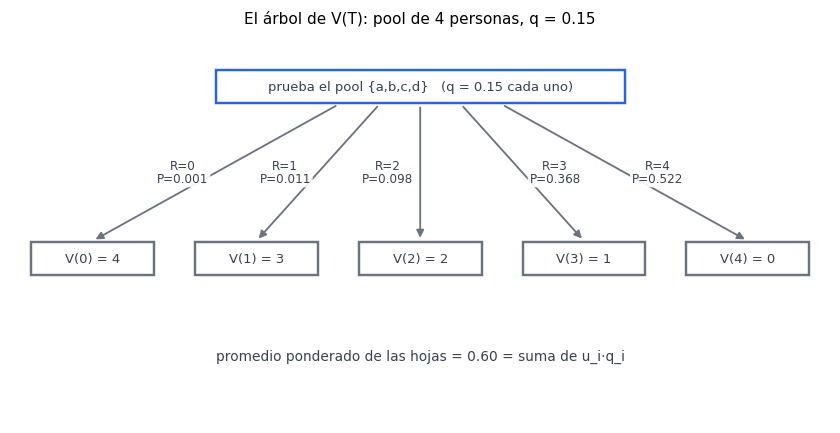

In [3]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
lienzo(ax, 'El árbol de V(T): pool de 4 personas, q = 0.15')

caja(ax, 0.5, 0.86, 'prueba el pool {a,b,c,d}   (q = 0.15 cada uno)', AZUL, w=0.5)
xs = np.linspace(0.10, 0.90, 5)
for R, x in enumerate(xs):
    caja(ax, x, 0.42, f'V({R}) = {V4[R]:.0f}', GRIS, w=0.15)
    flecha(ax, 0.5 + (x - 0.5) * 0.25, 0.815, x, 0.465,
           f'R={R}\nP={pmf4[R]:.3f}', 'der' if x > 0.5 else 'izq')
ax.text(0.5, 0.16,
        f'promedio ponderado de las hojas = {prior4:.2f} = suma de u_i·q_i',
        ha='center', fontsize=9, color=TINTA)
plt.show()

**Para discutir.** De las dos correcciones que apunta la obstrucción —
utilidad extraíble bajo el presupuesto restante, o descuento por las log G
pruebas de extracción — ¿cuál conserva mejor la intuición original?

## Acto 2. El caso: cinco personas, tres pruebas, dos árboles

Personas a, b, c, d, e, todas activas con p = 0.7 (sanas con q = 0.3), u = 1,
pools de a lo más 2. Una individual paga q = 0.3 hoy; el par paga 2q² = 0.18.
El miope nunca abre el par. Pero si el par {a,b} sale con conteo 1, cada
miembro queda sano con probabilidad 1/2, y una prueba adentro vale 0.5.

**La afirmación [VERIFICADO n=5, exacto].** El miope dinámico aumentado hace
tres individuales, vale 3q = 0.90 y coincide con el estático. El óptimo
dinámico aumentado abre el par, reentra tras conteo 1, y vale
q(3q²−3q+4) = 1.011: un 12.3% más con la misma información y presupuesto.

In [4]:
n, Bud, G = 5, 3, 2
p_caso = 0.7
q = 1.0 - p_caso
p_vec, u_vec = np.full(n, p_caso), np.ones(n)

v_gre = greedy_laminar_value(p_vec, u_vec, Bud, G)
v_est = static_greedy_value(p_vec, u_vec, Bud, G)
v_opt = dynamic_augmented_value(p_vec, u_vec, Bud, G)
v_rol = rollout_laminar_value(p_vec, u_vec, Bud, G)

# El mismo optimo, sumado a mano rama por rama sobre el arbol declarado.
rama_R0 = 2.0 + 2.0 * q            # cobra el par; luego {c} y {d}
rama_R1 = 0.5 * (1.0 + q) + 0.5    # reentra {a}: sano -> cobra 1 y {c}; activo -> {b} seguro
rama_R2 = 2.0 * q                  # par muerto; {c} y {d}
P_R0, P_R1, P_R2 = q * q, 2.0 * p_caso * q, p_caso * p_caso
v_arbol = P_R0 * rama_R0 + P_R1 * rama_R1 + P_R2 * rama_R2

assert abs(v_gre - 3.0 * q) < 1e-9
assert abs(v_gre - v_est) < 1e-9
assert abs(v_opt - q * (3 * q ** 2 - 3 * q + 4)) < 1e-9
assert abs(v_arbol - v_opt) < 1e-9
assert abs(v_rol - v_opt) < 1e-9

print(f'miope dinamico aumentado  {v_gre:.4f}   (= 3q; identico al estatico {v_est:.4f})')
print(f'optimo dinamico aumentado {v_opt:.4f}   (= q(3q^2-3q+4); arbol a mano {v_arbol:.4f})')
print(f'mejora {100 * (v_opt / v_gre - 1):.1f}%\n')
print(f'ramas del arbol optimo:')
print(f'  R=0  P={P_R0:.2f}  valor {rama_R0:.2f}   cobra {{a,b}}, luego {{c}} y {{d}}')
print(f'  R=1  P={P_R1:.2f}  valor {rama_R1:.2f}   reentra {{a}}: 1/2 cobra 1 y sigue {{c}}; 1/2 cobra {{b}} seguro')
print(f'  R=2  P={P_R2:.2f}  valor {rama_R2:.2f}   par muerto; {{c}} y {{d}}')

miope dinamico aumentado  0.9000   (= 3q; identico al estatico 0.9000)
optimo dinamico aumentado 1.0110   (= q(3q^2-3q+4); arbol a mano 1.0110)
mejora 12.3%

ramas del arbol optimo:
  R=0  P=0.09  valor 2.60   cobra {a,b}, luego {c} y {d}
  R=1  P=0.42  valor 1.15   reentra {a}: 1/2 cobra 1 y sigue {c}; 1/2 cobra {b} seguro
  R=2  P=0.49  valor 0.60   par muerto; {c} y {d}


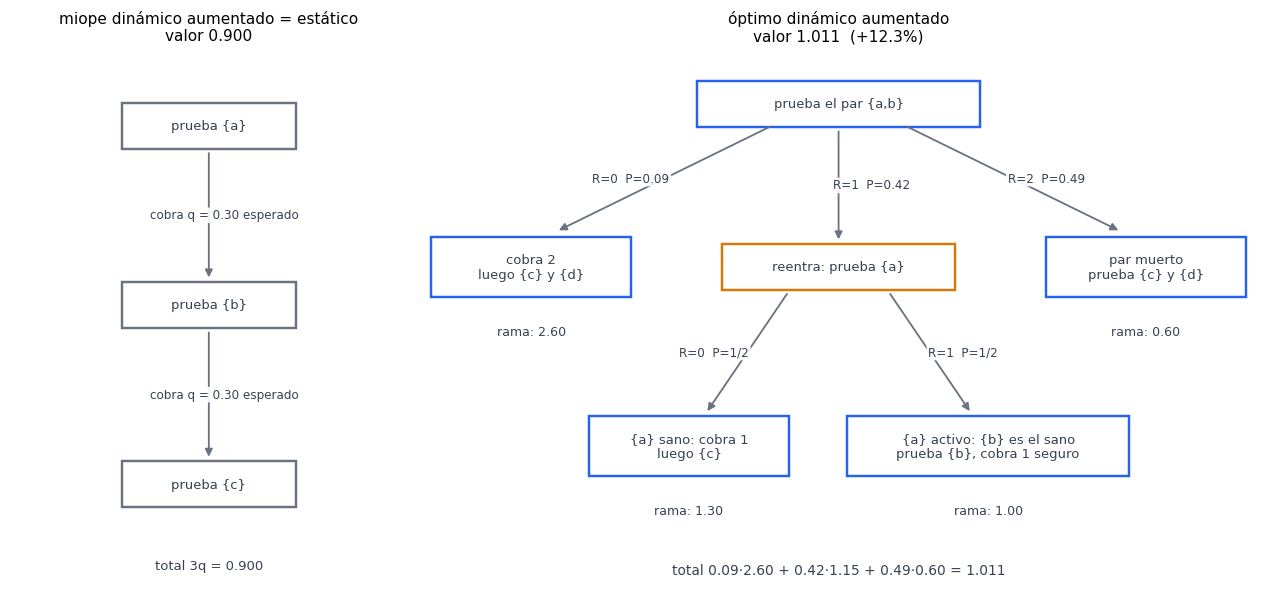

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 5.6),
                               gridspec_kw={'width_ratios': [1, 2.1]})
lienzo(ax1, f'miope dinámico aumentado = estático\nvalor {v_gre:.3f}')
lienzo(ax2, f'óptimo dinámico aumentado\nvalor {v_opt:.3f}  (+{100 * (v_opt / v_gre - 1):.1f}%)')

# --- miope: cadena de tres individuales (no reacciona a nada) ---
caja(ax1, 0.5, 0.86, 'prueba {a}', GRIS, w=0.44)
caja(ax1, 0.5, 0.53, 'prueba {b}', GRIS, w=0.44)
caja(ax1, 0.5, 0.20, 'prueba {c}', GRIS, w=0.44)
flecha(ax1, 0.5, 0.815, 0.5, 0.575, f'cobra q = {q:.2f} esperado', 'der')
flecha(ax1, 0.5, 0.485, 0.5, 0.245, f'cobra q = {q:.2f} esperado', 'der')
ax1.text(0.5, 0.045, f'total 3q = {v_gre:.3f}',
         ha='center', fontsize=8.6, color=TINTA)

# --- optimo: par, y cada conteo cambia el plan ---
caja(ax2, 0.50, 0.90, 'prueba el par {a,b}', AZUL, w=0.34)

caja(ax2, 0.13, 0.60, 'cobra 2\nluego {c} y {d}', AZUL, w=0.24, h=0.11)
caja(ax2, 0.50, 0.60, 'reentra: prueba {a}', AMBAR, w=0.28)
caja(ax2, 0.87, 0.60, 'par muerto\nprueba {c} y {d}', AZUL, w=0.24, h=0.11)

flecha(ax2, 0.42, 0.86, 0.16, 0.665, f'R=0  P={P_R0:.2f}', 'izq')
flecha(ax2, 0.50, 0.855, 0.50, 0.645, f'R=1  P={P_R1:.2f}', 'der')
flecha(ax2, 0.58, 0.86, 0.84, 0.665, f'R=2  P={P_R2:.2f}', 'der')

caja(ax2, 0.32, 0.27, '{a} sano: cobra 1\nluego {c}', AZUL, w=0.24, h=0.11)
caja(ax2, 0.68, 0.27, '{a} activo: {b} es el sano\nprueba {b}, cobra 1 seguro', AZUL,
     w=0.34, h=0.11)
flecha(ax2, 0.44, 0.555, 0.34, 0.33, 'R=0  P=1/2', 'izq')
flecha(ax2, 0.56, 0.555, 0.66, 0.33, 'R=1  P=1/2', 'der')

ax2.text(0.13, 0.475, f'rama: {rama_R0:.2f}', ha='center', fontsize=8.2, color=TINTA)
ax2.text(0.87, 0.475, f'rama: {rama_R2:.2f}', ha='center', fontsize=8.2, color=TINTA)
ax2.text(0.32, 0.145, f'rama: {1 + q:.2f}', ha='center', fontsize=8.2, color=TINTA)
ax2.text(0.68, 0.145, 'rama: 1.00', ha='center', fontsize=8.2, color=TINTA)
ax2.text(0.50, 0.035,
         f'total {P_R0:.2f}·{rama_R0:.2f} + {P_R1:.2f}·{rama_R1:.2f} + '
         f'{P_R2:.2f}·{rama_R2:.2f} = {v_arbol:.3f}',
         ha='center', fontsize=9, color=TINTA)
fig.tight_layout()
plt.show()

In [ ]:


qs = np.linspace(0.05, 0.95, 181)
suma_ramas = qs**2 * (2 + 2*qs) + 2*qs*(1 - qs)*(1 + qs/2) + (1 - qs)**2 * (2*qs)
polinomio = 3*qs**3 - 3*qs**2 + 4*qs
assert np.max(np.abs(suma_ramas - polinomio)) < 1e-12
ventaja = polinomio - 3*qs
assert np.min(ventaja) > 0

print('suma de ramas = 3q^3 - 3q^2 + 4q, identicas en 181 valores de q')
print(f'en q = 0.3: {3*0.3**3 - 3*0.3**2 + 4*0.3:.3f}  (el 1.011 del acto 2)')
print(f'ventaja sobre el miope, q(3q^2-3q+1): siempre positiva; minima en la rejilla {ventaja.min():.4f}')

suma de ramas = 3q^3 - 3q^2 + 4q, identicas en 181 valores de q
en q = 0.3: 1.011  (el 1.011 del acto 2)
ventaja sobre el miope, q(3q^2-3q+1): siempre positiva; minima en la rejilla 0.0429


**Paso 2 — el único nodo peleado.** El DP exacto de la celda siguiente
confirma que todas las decisiones del árbol tienen un ganador claro salvo una:
qué hacer tras el conteo 1 en {a,b}, con dos pruebas restantes. El estado:
exactamente uno de {a,b} está sano, cada uno con probabilidad 1/2, en espejo
(si a es el sano, b es el activo, y viceversa); c, d, e siguen frescas —
ninguna prueba las ha tocado, conservan su probabilidad q independiente, y una
individual sobre cualquiera de ellas aporta q.

Plan **reentrar** — probar {a}:

| resultado | probabilidad | qué pasa | rama |
|---|---|---|---|
| a sano (conteo 0) | 1/2 | cobra 1; la última prueba va a la fresca {c}: +q | 1 + q |
| a activo (conteo 1) | 1/2 | b queda sano por deducción, pero la deducción no paga: la última prueba se gasta en {b}, su conteo es 0 con certeza, y cobra 1 | 1 |

valor = (1/2)(1+q) + 1/2 = **1 + q/2**.

Plan **cruzar** — probar {a,c}:

| conteo de {a,c} | probabilidad | qué pasa | rama |
|---|---|---|---|
| 0 | q/2 | a y c sanos: cobra 2; la última prueba va a la fresca {d}: +q | 2 + q |
| 1 | 1/2 | dos casos posibles: (a sano, c activo), prob (1/2)(1−q), o (a activo, c sano), prob (1/2)q. Dado el conteo, P(a activo) = q — y si a es el activo, b es sano (por el par) y c es sano (por esta prueba). Así que b y c son AMBOS sanos con probabilidad q: la última prueba al par {b,c} cobra 2 con prob q | 2q |
| 2 | (1−q)/2 | a y c activos ⟹ b sano seguro; la última prueba {b} cobra 1 | 1 |

valor = (q/2)(2+q) + (1/2)(2q) + ((1−q)/2)(1) = **(q² + 3q + 1)/2**. En la
rama de conteo 1 la alternativa era probar {a} solo — dado ese conteo está
sano con probabilidad 1−q y cobraría 1−q —; probar {b,c} rinde 2q, que gana
cuando q ≥ 1/3, cierto en toda la zona del empate.

**Paso 3 — el umbral es la raíz de la resta.** cruzar − reentrar =
(q²+3q+1)/2 − (1+q/2) = **(q² + 2q − 1)/2**. La cuadrática q² + 2q − 1 = 0
tiene raíces q = −1 ± √2; la única en [0,1] es q = √2 − 1 ≈ 0.414. El signo de
la resta decide el plan: negativa para q < √2−1 (reentrar gana y el árbol del
par es el óptimo exacto), positiva para √2−1 < q ≤ 1/2 (cruzar gana por poco y
el óptimo se separa apenas del plan del par). En términos de actividad,
p = 1−q, el cambio ocurre en p = 2−√2 ≈ 0.586. Un cambio de política en una
raíz, no gradual — la firma de que todo aquí son polinomios.

In [7]:
# Verificacion de los pasos 2 y 3 contra el DP exacto: los valores de ambos
# planes (con continuacion optima), la resta y su raiz.
q_nodo = 0.45                       # p = 0.55, bajo el umbral: cruzar gana
comparacion = {}
for q_ in (0.45, 0.35):             # bajo y sobre el umbral (raiz en q = 0.4142)
    ev_ = ExactPolicyEvaluator(np.full(5, 1.0 - q_), np.ones(5), B=3, G=2)
    V_ = hacer_V(ev_)
    w1, c1 = estado_tras(ev_, 0b00011, 1)              # par {a,b} con conteo 1
    Q_re = Q_en(ev_, V_, 2, w1, c1, 0b00001)           # reentrar: prueba {a}
    Q_cr = Q_en(ev_, V_, 2, w1, c1, 0b00101)           # cruzar: prueba {a,c}
    assert abs(Q_re - (1.0 + q_ / 2.0)) < 1e-9
    assert abs(Q_cr - (q_ ** 2 + 3 * q_ + 1) / 2.0) < 1e-9
    assert abs((Q_cr - Q_re) - (q_ ** 2 + 2 * q_ - 1) / 2.0) < 1e-9
    mejor_global = max(Q_en(ev_, V_, 2, w1, c1, t) for t in ev_.pools)
    assert abs(mejor_global - max(Q_re, Q_cr)) < 1e-9   # ningun tercer plan gana en el nodo
    comparacion[q_] = (Q_re, Q_cr)

assert comparacion[0.45][1] > comparacion[0.45][0]     # bajo el umbral cruza
assert comparacion[0.35][0] > comparacion[0.35][1]     # sobre el umbral reentra

raiz = float(np.roots([1.0, 2.0, -1.0]).max())         # q^2 + 2q - 1 = 0
assert abs(raiz - (math.sqrt(2.0) - 1.0)) < 1e-12

for q_, (Q_re, Q_cr) in comparacion.items():
    lado = 'cruzar gana' if Q_cr > Q_re else 'reentrar gana'
    print(f'q = {q_:.2f} (p = {1 - q_:.2f}):  reentrar {Q_re:.4f}   cruzar {Q_cr:.4f}   '
          f'resta {(Q_cr - Q_re):+.4f}   -> {lado}')
print(f'\nla resta es (q^2 + 2q - 1)/2; cero exacto en q = sqrt(2)-1 = {math.sqrt(2) - 1:.4f}')

q = 0.45 (p = 0.55):  reentrar 1.2250   cruzar 1.2762   resta +0.0513   -> cruzar gana
q = 0.35 (p = 0.65):  reentrar 1.1750   cruzar 1.0863   resta -0.0888   -> reentrar gana

la resta es (q^2 + 2q - 1)/2; cero exacto en q = sqrt(2)-1 = 0.4142


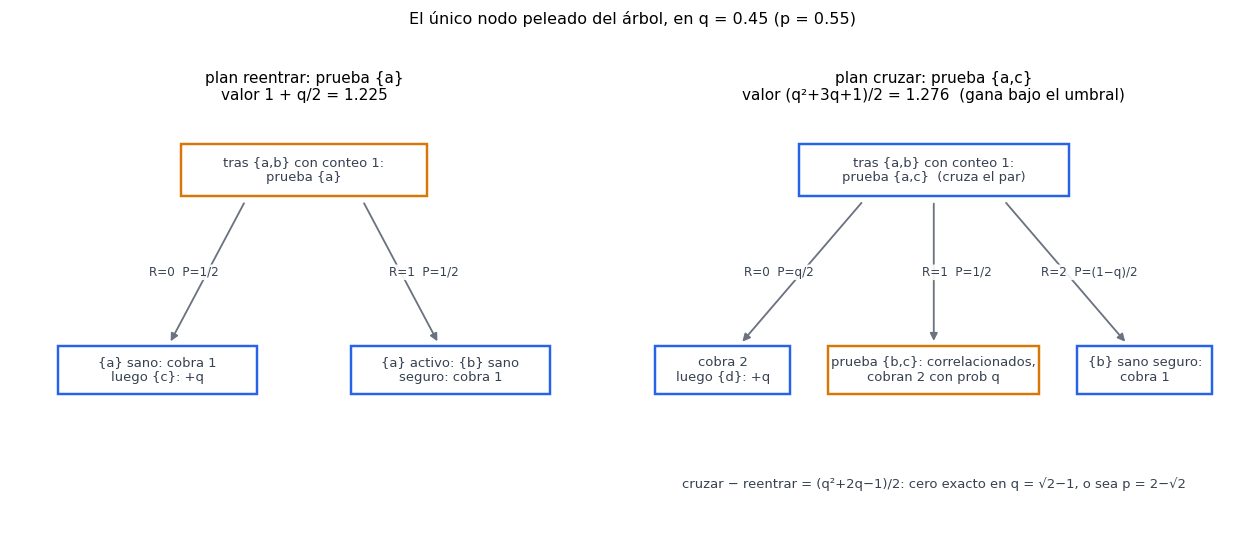

In [8]:
Q_re, Q_cr = comparacion[q_nodo]
qn = q_nodo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.9))
lienzo(ax1, f'plan reentrar: prueba {{a}}\nvalor 1 + q/2 = {Q_re:.3f}')
lienzo(ax2, f'plan cruzar: prueba {{a,c}}\nvalor (q²+3q+1)/2 = {Q_cr:.3f}  (gana bajo el umbral)')

# --- reentrar ---
caja(ax1, 0.5, 0.86, 'tras {a,b} con conteo 1:\nprueba {a}', AMBAR, w=0.42, h=0.12)
caja(ax1, 0.25, 0.40, '{a} sano: cobra 1\nluego {c}: +q', AZUL, w=0.34, h=0.11)
caja(ax1, 0.75, 0.40, '{a} activo: {b} sano\nseguro: cobra 1', AZUL, w=0.34, h=0.11)
flecha(ax1, 0.40, 0.79, 0.27, 0.46, 'R=0  P=1/2', 'izq')
flecha(ax1, 0.60, 0.79, 0.73, 0.46, 'R=1  P=1/2', 'der')

# --- cruzar ---
caja(ax2, 0.5, 0.86, 'tras {a,b} con conteo 1:\nprueba {a,c}  (cruza el par)', AZUL,
     w=0.46, h=0.12)
caja(ax2, 0.14, 0.40, 'cobra 2\nluego {d}: +q', AZUL, w=0.23, h=0.11)
caja(ax2, 0.50, 0.40, 'prueba {b,c}: correlacionados,\ncobran 2 con prob q', AMBAR,
     w=0.36, h=0.11)
caja(ax2, 0.86, 0.40, '{b} sano seguro:\ncobra 1', AZUL, w=0.23, h=0.11)
flecha(ax2, 0.38, 0.79, 0.17, 0.46, f'R=0  P=q/2', 'izq')
flecha(ax2, 0.50, 0.79, 0.50, 0.46, 'R=1  P=1/2', 'der')
flecha(ax2, 0.62, 0.79, 0.83, 0.46, f'R=2  P=(1−q)/2', 'der')
ax2.text(0.5, 0.13,
         f'cruzar − reentrar = (q²+2q−1)/2: cero exacto en q = √2−1, o sea p = 2−√2',
         ha='center', fontsize=8.6, color=TINTA)
fig.suptitle(f'El único nodo peleado del árbol, en q = {qn:.2f} (p = {1 - qn:.2f})',
             fontsize=10.5, y=1.02)
fig.tight_layout()
plt.show()

In [9]:
ps = np.round(np.arange(0.50, 0.91, 0.05), 2)
umbral = 2.0 - math.sqrt(2.0)
filas = []
for p_base in ps:
    p_v, u_v = np.full(n, float(p_base)), np.ones(n)
    qq = 1.0 - p_base
    v_o = dynamic_augmented_value(p_v, u_v, Bud, G)
    v_g = greedy_laminar_value(p_v, u_v, Bud, G)
    v_r = rollout_laminar_value(p_v, u_v, Bud, G)
    v_e = static_greedy_value(p_v, u_v, Bud, G)
    assert abs(v_g - v_e) < 1e-9
    assert abs(v_g - 3.0 * qq) < 1e-9
    assert abs(v_r - qq * (3 * qq ** 2 - 3 * qq + 4)) < 1e-9
    if p_base >= umbral:
        assert abs(v_o - v_r) < 1e-9
    else:
        assert v_o > v_r + 1e-9
    filas.append((p_base, v_o, v_g, v_r))

arr = np.array(filas)
print(f'n={n}, B={Bud}, G={G}, homogeneo; umbral 2-sqrt(2) = {umbral:.4f}')
print(f"{'p':>5} {'optimo':>8} {'miope':>8} {'anticipa':>9} {'miope/opt':>10}")
for p_base, v_o, v_g, v_r in filas:
    print(f'{p_base:5.2f} {v_o:8.4f} {v_g:8.4f} {v_r:9.4f} {v_g / v_o:10.4f}')

n=5, B=3, G=2, homogeneo; umbral 2-sqrt(2) = 0.5858
    p   optimo    miope  anticipa  miope/opt
 0.50   1.6875   1.5000    1.6250     0.8889
 0.55   1.4912   1.3500    1.4659     0.9053
 0.60   1.3120   1.2000    1.3120     0.9146
 0.65   1.1611   1.0500    1.1611     0.9043
 0.70   1.0110   0.9000    1.0110     0.8902
 0.75   0.8594   0.7500    0.8594     0.8727
 0.80   0.7040   0.6000    0.7040     0.8523
 0.85   0.5426   0.4500    0.5426     0.8293
 0.90   0.3730   0.3000    0.3730     0.8043


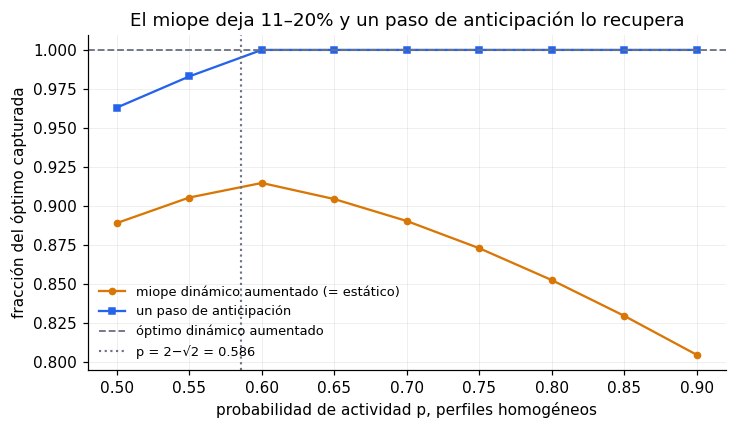

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(arr[:, 0], arr[:, 2] / arr[:, 1], color=AMBAR, marker='o', ms=4,
        label='miope dinámico aumentado (= estático)')
ax.plot(arr[:, 0], arr[:, 3] / arr[:, 1], color=AZUL, marker='s', ms=4,
        label='un paso de anticipación')
ax.axhline(1.0, color=GRIS, ls='--', lw=1.2, label='óptimo dinámico aumentado')
ax.axvline(umbral, color=GRIS, ls=':', lw=1.4,
           label=f'p = 2−√2 = {umbral:.3f}')
ax.set_xlabel('probabilidad de actividad p, perfiles homogéneos')
ax.set_ylabel('fracción del óptimo capturada')
ax.set_title('El miope deja 11–20% y un paso de anticipación lo recupera')
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
fig.tight_layout()
plt.show()

**Coda [VERIFICADO n≤6].** El umbral no es solo descriptivo: es donde la
restricción laminar más pierde. Una búsqueda adversaria exacta (200 mil
instancias evaluadas por enumeración, doble verificación independiente)
encontró el peor caso de la clase laminar en B=3 parándose sola en el umbral:
un cúmulo de cuatro personas idénticas en p = 0.586 ≈ 2−√2 con u = 2, más
anclas casi limpias. La mejor biblioteca laminar deja ahí 14.3% del óptimo, y
la brecha crece con n.

In [11]:
# El peor caso adversarial de la clase laminar (B=3) vive en el umbral 2-sqrt(2).
anc_p, anc_u = [0.01, 0.01], [0.324219, 0.87875]
filas_coda = []
for extra in (0, 1, 2):
    p_c = np.array([0.586] * 4 + anc_p[:extra])
    u_c = np.array([2.0] * 4 + anc_u[:extra])
    q_c = four_quantities(p_c, u_c, B=3, G=3)
    filas_coda.append((4 + extra, q_c['ratio_laminar_opt']))

assert abs(filas_coda[2][1] - 0.8571) < 1e-3     # el record doble-verificado
assert filas_coda[0][1] > filas_coda[1][1] > filas_coda[2][1]   # empeora con n

print('cumulo de 4 en p = 0.586 (~2-sqrt2), u = 2, + anclas casi limpias; B=3, G=3')
for n_c, r_c in filas_coda:
    print(f'  n={n_c}:  mejor laminar / optimo = {r_c:.4f}')

cumulo de 4 en p = 0.586 (~2-sqrt2), u = 2, + anclas casi limpias; B=3, G=3
  n=4:  mejor laminar / optimo = 1.0000
  n=5:  mejor laminar / optimo = 0.9529
  n=6:  mejor laminar / optimo = 0.8571


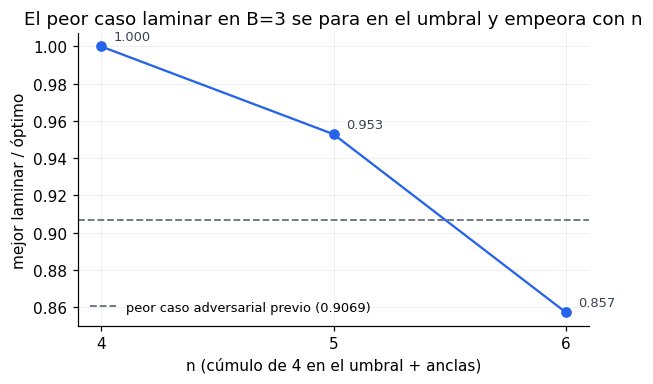

In [12]:
arr_c = np.array(filas_coda)
fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(arr_c[:, 0], arr_c[:, 1], color=AZUL, marker='o', ms=6)
ax.axhline(0.9069, color=GRIS, ls='--', lw=1.2,
           label='peor caso adversarial previo (0.9069)')
for n_c, r_c in filas_coda:
    ax.annotate(f'{r_c:.3f}', (n_c, r_c), textcoords='offset points',
                xytext=(8, 4), fontsize=8.5, color=TINTA)
ax.set_xticks([4, 5, 6])
ax.set_xlabel('n (cúmulo de 4 en el umbral + anclas)')
ax.set_ylabel('mejor laminar / óptimo')
ax.set_title('El peor caso laminar en B=3 se para en el umbral y empeora con n')
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
fig.tight_layout()
plt.show()

**Lectura.** La brecha del miope crece con la prevalencia y la anticipación la
cierra exactamente desde p = 2−√2. El umbral no es misterioso: es la raíz del
empate de un solo nodo — reentrar (laminar) contra cruzar (no laminar) tras el
conteo 1 —, y bajo el umbral la jugada óptima es la cruzada, que es justo la
clase de acción que la restricción laminar prohíbe. Con conteo binario nada de
esto existe: el conteo intermedio es lo que el dinámico binario no puede ver.

**Para discutir.** El teorema estático de p > 1/2 acierta con el miope y el
estático, y el óptimo dinámico aumentado se le escapa por la reentrada. ¿Vale
enunciar la familia con su umbral exacto en el paper, o esperamos el mecanismo
unificado con el ejemplo canónico?

## Acto 4. La misma prueba vale siete veces más después de un conteo

El setup: cuatro personas {a,b,c,d}, todas con probabilidad q = 0.05 de estar
sanas, u = 1, pools de a lo más 3. 

In [13]:
q_sano = 0.05
ev_s = ExactPolicyEvaluator(np.full(4, 1.0 - q_sano), np.ones(4), B=3, G=3)

# El testigo: la ganancia de probar {a} antes y despues del trio con conteo 2.
g_raiz = ganancia(ev_s, ev_s.all_worlds, 0, 0b0001)
w2, c2 = estado_tras(ev_s, 0b0111, 2)
g_tras = ganancia(ev_s, w2, c2, 0b0001)
assert abs(g_raiz - q_sano) < 1e-12
assert abs(g_tras - 1.0 / 3.0) < 1e-12

# La enumeracion completa: monotonia si, submodularidad no.
genuinas, contables, monotona = 0, 0, True
for t0 in ev_s.pools:
    for R, compat in enumerate(ev_s.outcome_worlds[t0]):
        child = ev_s.all_worlds & compat
        if ev_s.mass(child) <= 0.0:
            continue
        c1 = t0 if R == 0 else 0
        for t in ev_s.pools:
            if t == t0:
                continue
            g0 = ganancia(ev_s, ev_s.all_worlds, 0, t)
            g1 = ganancia(ev_s, child, c1, t)
            monotona &= (g0 >= -1e-12 and g1 >= -1e-12)
            if g1 > g0 + 1e-9:
                if t & c1:
                    contables += 1
                else:
                    genuinas += 1

assert monotona, 'la monotonia adaptativa deberia cumplirse siempre'
assert genuinas > 0, 'se esperaban violaciones genuinas'

print(f'testigo: ganancia de probar {{a}} sin historial {g_raiz:.4f}u; '
      f'tras el trio con conteo 2, {g_tras:.4f}u  (factor {g_tras / g_raiz:.1f})')
print(f'enumeracion n=4, G=3: monotonia OK en todos los pares; '
      f'violaciones genuinas {genuinas}, contables {contables}')

testigo: ganancia de probar {a} sin historial 0.0500u; tras el trio con conteo 2, 0.3333u  (factor 6.7)
enumeracion n=4, G=3: monotonia OK en todos los pares; violaciones genuinas 120, contables 96


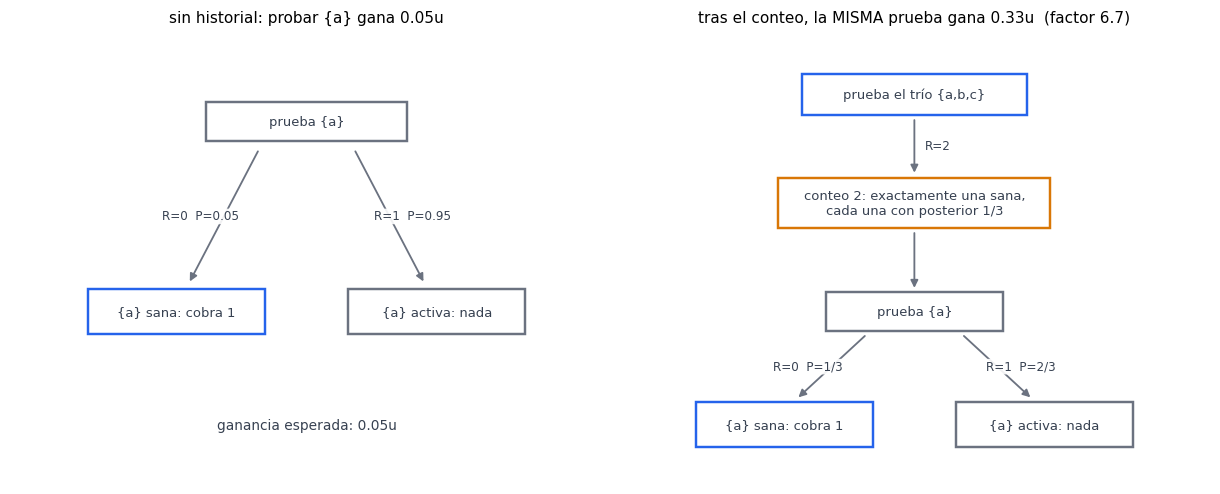

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.6))
lienzo(ax1, f'sin historial: probar {{a}} gana {g_raiz:.2f}u')
lienzo(ax2, f'tras el conteo, la MISMA prueba gana {g_tras:.2f}u  '
            f'(factor {g_tras / g_raiz:.1f})')

# --- sin historial ---
caja(ax1, 0.5, 0.80, 'prueba {a}', GRIS, w=0.34)
caja(ax1, 0.28, 0.38, '{a} sana: cobra 1', AZUL, w=0.30, h=0.10)
caja(ax1, 0.72, 0.38, '{a} activa: nada', GRIS, w=0.30, h=0.10)
flecha(ax1, 0.42, 0.74, 0.30, 0.44, f'R=0  P={q_sano:.2f}', 'izq')
flecha(ax1, 0.58, 0.74, 0.70, 0.44, f'R=1  P={1 - q_sano:.2f}', 'der')
ax1.text(0.5, 0.12, f'ganancia esperada: {q_sano:.2f}u', ha='center',
         fontsize=9, color=TINTA)

# --- con historial ---
caja(ax2, 0.5, 0.86, 'prueba el trío {a,b,c}', AZUL, w=0.38, h=0.09)
caja(ax2, 0.5, 0.62, 'conteo 2: exactamente una sana,\ncada una con posterior 1/3', AMBAR,
     w=0.46, h=0.11)
flecha(ax2, 0.5, 0.81, 0.5, 0.68, 'R=2', 'der')
caja(ax2, 0.5, 0.38, 'prueba {a}', GRIS, w=0.30)
flecha(ax2, 0.5, 0.56, 0.5, 0.425, '', 'der')
caja(ax2, 0.28, 0.13, '{a} sana: cobra 1', AZUL, w=0.30, h=0.10)
caja(ax2, 0.72, 0.13, '{a} activa: nada', GRIS, w=0.30, h=0.10)
flecha(ax2, 0.42, 0.33, 0.30, 0.185, 'R=0  P=1/3', 'izq')
flecha(ax2, 0.58, 0.33, 0.70, 0.185, 'R=1  P=2/3', 'der')
fig.tight_layout()
plt.show()